# **`Etash Ashwin 22MIA1044`**

Dataset Simulation Generator

In [2]:
!pip install faker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 25.5 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
from faker import Faker
import random

fake = Faker()

# -----------------------------
# CONFIGURATION
# -----------------------------

NUM_STUDENTS = 1000

np.random.seed(42)
random.seed(42)

# -----------------------------
# Sample Feedback Sentences
# -----------------------------

positive_feedback = [
    "I am managing studies well.",
    "Course workload is balanced.",
    "I enjoy learning new topics.",
    "Faculty support is helpful."
]

neutral_feedback = [
    "Everything is okay.",
    "Assignments are manageable.",
    "Routine semester."
]

negative_feedback = [
    "I feel overwhelmed.",
    "Too much academic pressure.",
    "Hard to keep up with deadlines.",
    "Feeling stressed and tired."
]


# -----------------------------
# Generate Behaviour Data
# -----------------------------

data = []

for i in range(NUM_STUDENTS):

    student_id = f"S{i+1:04}"

    # LMS logins per week
    lms_logins = np.random.poisson(5)

    # login drop percentage
    login_drop = np.clip(np.random.normal(0.2,0.25),0,1)

    # attendance %
    attendance = np.clip(np.random.normal(80,20),20,100)

    attendance_trend = np.random.uniform(-40,10)

    # submission delays (days)
    avg_delay = abs(np.random.normal(2,3))

    late_submission_ratio = np.clip(np.random.normal(0.3,0.3),0,1)

    # night activity ratio
    night_activity = np.clip(np.random.beta(2,5),0,1)

    # session duration
    avg_session_duration = np.clip(
        np.random.normal(40,20),5,120
    )

    # sentiment category

    sentiment_type = random.choices(
        ["positive","neutral","negative"],
        weights=[0.4,0.3,0.3]
    )[0]

    if sentiment_type == "positive":
        feedback = random.choice(positive_feedback)
        sentiment_score = np.random.uniform(0.4,1)

    elif sentiment_type == "neutral":
        feedback = random.choice(neutral_feedback)
        sentiment_score = np.random.uniform(-0.2,0.2)

    else:
        feedback = random.choice(negative_feedback)
        sentiment_score = np.random.uniform(-1,-0.4)

    # -----------------------------
    # Risk Score Logic (REALISTIC)
    # -----------------------------

    risk_score = 0

    if attendance < 60:
        risk_score += 25

    if attendance_trend < -20:
        risk_score += 20

    if avg_delay > 5:
        risk_score += 15

    if late_submission_ratio > 0.6:
        risk_score += 15

    if sentiment_score < -0.4:
        risk_score += 20

    if login_drop > 0.5:
        risk_score += 10

    if night_activity > 0.6:
        risk_score += 10

    risk_score += random.randint(0,10)

    risk_score = np.clip(risk_score,0,100)

    # Risk Category

    if risk_score < 35:
        burnout_risk = "Low"

    elif risk_score < 70:
        burnout_risk = "Medium"

    else:
        burnout_risk = "High"


    # Dropout Probability

    dropout_probability = np.clip(
        risk_score + np.random.normal(0,10),
        0,
        100
    )


    # Academic Disengagement Indicator

    disengagement = "No"

    if attendance < 55 or lms_logins < 2:
        disengagement = "Yes"


    data.append({

        "StudentID":student_id,

        "LMS_Logins_Per_Week":lms_logins,

        "Login_Drop_Ratio":round(login_drop,2),

        "Attendance_Percentage":round(attendance,2),

        "Attendance_Trend":round(attendance_trend,2),

        "Avg_Assignment_Delay_Days":round(avg_delay,2),

        "Late_Submission_Ratio":
            round(late_submission_ratio,2),

        "Night_Activity_Ratio":
            round(night_activity,2),

        "Avg_Session_Duration_Min":
            round(avg_session_duration,2),

        "Feedback_Text":feedback,

        "Sentiment_Score":
            round(sentiment_score,2),

        "Burnout_Risk_Score":
            int(risk_score),

        "Burnout_Risk_Level":
            burnout_risk,

        "Dropout_Probability":
            int(dropout_probability),

        "Academic_Disengagement":
            disengagement

    })


# -----------------------------
# Save Dataset
# -----------------------------

df = pd.DataFrame(data)

df.to_csv(
    "student_burnout_dataset.csv",
    index=False
)

print("Dataset Generated Successfully!")

df.head()

Dataset Generated Successfully!


,StudentID,LMS_Logins_Per_Week,Login_Drop_Ratio,Attendance_Percentage,Attendance_Trend,Avg_Assignment_Delay_Days,Late_Submission_Ratio,Night_Activity_Ratio,Avg_Session_Duration_Min,Feedback_Text,Sentiment_Score,Burnout_Risk_Score,Burnout_Risk_Level,Dropout_Probability,Academic_Disengagement
0,S0001,5,0.59,95.35,-38.97,0.26,0.14,0.26,56.33,Everything is okay.,-0.14,34,Low,18,No
1,S0002,5,0.06,82.22,-9.62,0.20,0.58,0.38,29.33,Course workload is balanced.,0.95,1,Low,0,No
2,S0003,5,0.38,83.43,-35.58,1.03,0.00,0.44,17.39,Routine semester.,0.12,21,Low,22,No
3,S0004,4,0.35,97.75,-3.55,0.52,0.21,0.23,17.87,Everything is okay.,0.09,0,Low,0,No
4,S0005,8,0.00,96.44,-38.73,2.26,0.61,0.40,24.21,Course workload is balanced.,0.45,43,Medium,50,No


Convert Labels into Machine Learning Format

In [6]:
df["Risk_Label"] = df["Burnout_Risk_Level"].map({
    "Low":0,
    "Medium":1,
    "High":2
})

df.head()

,StudentID,LMS_Logins_Per_Week,Login_Drop_Ratio,Attendance_Percentage,Attendance_Trend,Avg_Assignment_Delay_Days,Late_Submission_Ratio,Night_Activity_Ratio,Avg_Session_Duration_Min,Feedback_Text,Sentiment_Score,Burnout_Risk_Score,Burnout_Risk_Level,Dropout_Probability,Academic_Disengagement,Risk_Label
0,S0001,5,0.59,95.35,-38.97,0.26,0.14,0.26,56.33,Everything is okay.,-0.14,34,Low,18,No,0
1,S0002,5,0.06,82.22,-9.62,0.20,0.58,0.38,29.33,Course workload is balanced.,0.95,1,Low,0,No,0
2,S0003,5,0.38,83.43,-35.58,1.03,0.00,0.44,17.39,Routine semester.,0.12,21,Low,22,No,0
3,S0004,4,0.35,97.75,-3.55,0.52,0.21,0.23,17.87,Everything is okay.,0.09,0,Low,0,No,0
4,S0005,8,0.00,96.44,-38.73,2.26,0.61,0.40,24.21,Course workload is balanced.,0.45,43,Medium,50,No,1


Select Features

In [7]:
X = df[[
"LMS_Logins_Per_Week",
"Login_Drop_Ratio",
"Attendance_Percentage",
"Attendance_Trend",
"Avg_Assignment_Delay_Days",
"Late_Submission_Ratio",
"Night_Activity_Ratio",
"Avg_Session_Duration_Min",
"Sentiment_Score"
]]

y = df["Risk_Label"]

Train Test Split

In [8]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42
)

Train ML Model

In [9]:
!pip install scikit-learn

In [10]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

model.fit(X_train,y_train)

RandomForestClassifier()

In [11]:
# Check Accuracy
from sklearn.metrics import accuracy_score

pred = model.predict(X_test)

accuracy_score(y_test,pred)

0.925

Predict Risk Score

In [13]:
import pandas as pd

sample = pd.DataFrame([{

"LMS_Logins_Per_Week":3,
"Login_Drop_Ratio":0.6,
"Attendance_Percentage":55,
"Attendance_Trend":-25,
"Avg_Assignment_Delay_Days":6,
"Late_Submission_Ratio":0.7,
"Night_Activity_Ratio":0.8,
"Avg_Session_Duration_Min":20,
"Sentiment_Score":-0.7

}])

model.predict(sample)

array([2])

In [14]:
prediction = model.predict(sample)[0]

risk_map = {
0:"Low Risk",
1:"Medium Risk",
2:"High Risk"
}

print("Burnout Risk :",risk_map[prediction])

Burnout Risk : High Risk


Key Behavioural Triggers (Explainable AI)

In [15]:
!pip install shap

In [16]:
import shap

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test)

import shap

explainer = shap.Explainer(model, X_train)

/tmp/ipython-input-561/2940161786.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test)
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:743: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:743: Futu

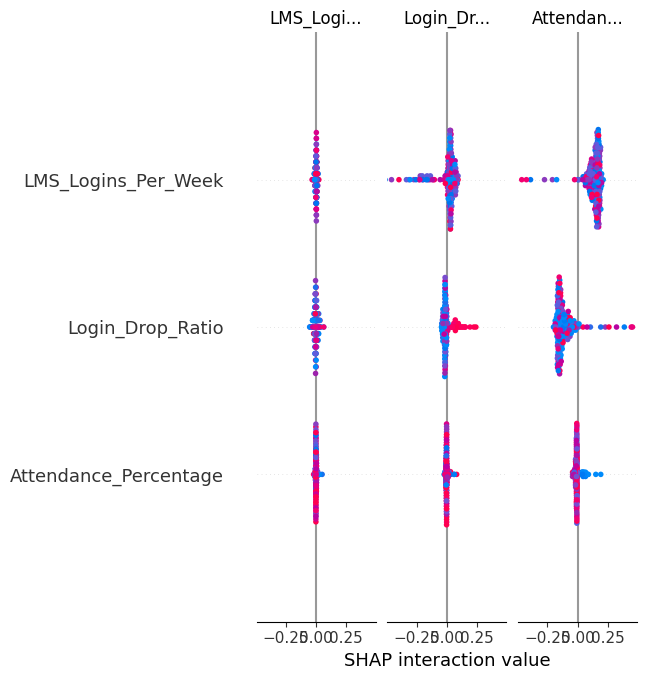

In [17]:
shap.summary_plot(shap_values, X_test)

In [25]:
import shap
explainer = shap.Explainer(model, X_train)
shap_values = explainer(sample)

In [26]:
predicted_class = model.predict(sample)[0]
print(predicted_class)

0


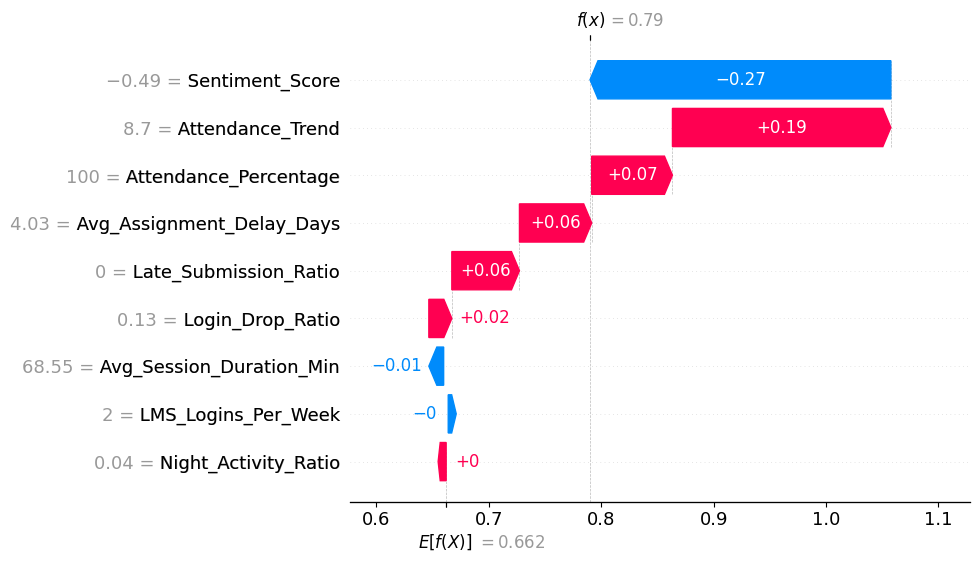

In [27]:
shap.plots.waterfall(
shap_values[0,:,predicted_class]
)

Extract Top Triggers

In [28]:
import pandas as pd
import numpy as np

impacts = shap_values.values[0,:,predicted_class]

feature_importance = pd.DataFrame({

"Feature":sample.columns,
"Impact":impacts

})

feature_importance["AbsImpact"] = np.abs(feature_importance["Impact"])

top_triggers = feature_importance.sort_values(
"AbsImpact",
ascending=False
).head(3)

top_triggers

,Feature,Impact,AbsImpact
8,Sentiment_Score,-0.267672,0.267672
3,Attendance_Trend,0.194319,0.194319
2,Attendance_Percentage,0.071850,0.071850


# **Recommended intervention strategy**

Create Intervention Engine Function

In [29]:
def recommend_intervention(student_row):

    actions = []

    # Attendance Problems
    if student_row["Attendance_Percentage"] < 60:
        actions.append(
        "Schedule Faculty Counseling Session"
        )

    # Attendance dropping fast
    if student_row["Attendance_Trend"] < -20:
        actions.append(
        "Early Academic Warning Notification"
        )

    # Assignment Issues
    if student_row["Avg_Assignment_Delay_Days"] > 5:
        actions.append(
        "Provide Assignment Deadline Extension Support"
        )

    if student_row["Late_Submission_Ratio"] > 0.6:
        actions.append(
        "Academic Mentor Follow-up"
        )

    # Mental Stress
    if student_row["Sentiment_Score"] < -0.4:
        actions.append(
        "Mental Wellness Counseling Recommended"
        )

    # LMS disengagement
    if student_row["LMS_Logins_Per_Week"] < 2:
        actions.append(
        "Learning Engagement Monitoring"
        )

    # Sleep behaviour
    if student_row["Night_Activity_Ratio"] > 0.6:
        actions.append(
        "Sleep Hygiene Awareness Program"
        )

    # No issues
    if len(actions) == 0:
        actions.append(
        "Regular Monitoring — No Immediate Intervention"
        )

    return actions

Apply For Entire Dataset

In [30]:
df["Recommended_Intervention"] = df.apply(
    recommend_intervention,
    axis=1
)

View Output

In [31]:
df[[
"StudentID",
"Burnout_Risk_Level",
"Recommended_Intervention"
]].head()

,StudentID,Burnout_Risk_Level,Recommended_Intervention
0,S0001,Low,[Early Academic Warning Notification]
1,S0002,Low,[Regular Monitoring — No Immediate Intervention]
2,S0003,Low,[Early Academic Warning Notification]
3,S0004,Low,[Regular Monitoring — No Immediate Intervention]
4,S0005,Medium,"[Early Academic Warning Notification, Academic..."


In [32]:
student = X_test.iloc[[0]]

prediction = model.predict(student)[0]

risk_map = {
0:"Low",
1:"Medium",
2:"High"
}

print("Risk Level :",risk_map[prediction])


student_row = df.iloc[student.index[0]]

recommendation = recommend_intervention(student_row)

print("\nRecommended Intervention:")

for action in recommendation:
    print("-",action)

Risk Level : Low

Recommended Intervention:
- Mental Wellness Counseling Recommended


Recommendations - Save updated dataset

In [33]:
df.to_csv(
"student_burnout_dataset_with_actions.csv",
index=False
)

# **Visualization**

In [1]:
!pip install plotly

In [5]:
!pip install plotly seaborn --quiet

In [6]:
import pandas as pd

df = pd.read_csv("/content/student_burnout_dataset_with_actions.csv")

df.head()

,StudentID,LMS_Logins_Per_Week,Login_Drop_Ratio,Attendance_Percentage,Attendance_Trend,Avg_Assignment_Delay_Days,Late_Submission_Ratio,Night_Activity_Ratio,Avg_Session_Duration_Min,Feedback_Text,Sentiment_Score,Burnout_Risk_Score,Burnout_Risk_Level,Dropout_Probability,Academic_Disengagement,Risk_Label,Recommended_Intervention
0,S0001,5,0.59,95.35,-38.97,0.26,0.14,0.26,56.33,Everything is okay.,-0.14,34,Low,18,No,0,['Early Academic Warning Notification']
1,S0002,5,0.06,82.22,-9.62,0.20,0.58,0.38,29.33,Course workload is balanced.,0.95,1,Low,0,No,0,['Regular Monitoring — No Immediate Interventi...
2,S0003,5,0.38,83.43,-35.58,1.03,0.00,0.44,17.39,Routine semester.,0.12,21,Low,22,No,0,['Early Academic Warning Notification']
3,S0004,4,0.35,97.75,-3.55,0.52,0.21,0.23,17.87,Everything is okay.,0.09,0,Low,0,No,0,['Regular Monitoring — No Immediate Interventi...
4,S0005,8,0.00,96.44,-38.73,2.26,0.61,0.40,24.21,Course workload is balanced.,0.45,43,Medium,50,No,1,"['Early Academic Warning Notification', 'Acade..."


1. Risk Score Gauge Meter (Overall Students)

In [7]:
import plotly.graph_objects as go

avg_risk = df["Burnout_Risk_Score"].mean()

fig = go.Figure(go.Indicator(
    mode="gauge+number",
    value=avg_risk,
    title={'text': "Average Burnout Risk Score"},
    gauge={
        'axis': {'range': [0,100]},

        'steps':[
            {'range':[0,33]},
            {'range':[33,66]},
            {'range':[66,100]}
        ]
    }
))

fig.show()

2. Burnout Trend Graph (All Students Behaviour)

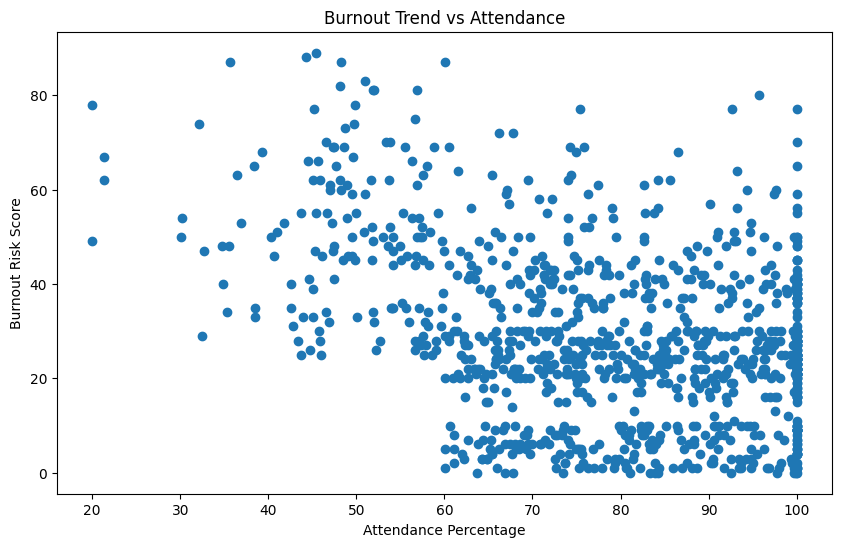

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(
    df["Attendance_Percentage"],
    df["Burnout_Risk_Score"],
)

plt.xlabel("Attendance Percentage")
plt.ylabel("Burnout Risk Score")

plt.title("Burnout Trend vs Attendance")

plt.show()

3. Dropout Probability Chart

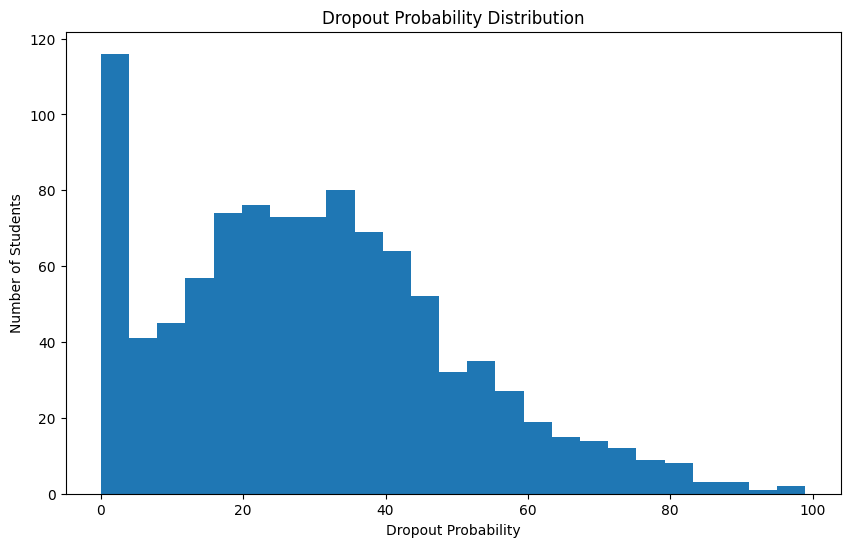

In [9]:
plt.figure(figsize=(10,6))

plt.hist(
    df["Dropout_Probability"],
    bins=25
)

plt.xlabel("Dropout Probability")
plt.ylabel("Number of Students")

plt.title("Dropout Probability Distribution")

plt.show()

4. Student Ranking Leaderboard

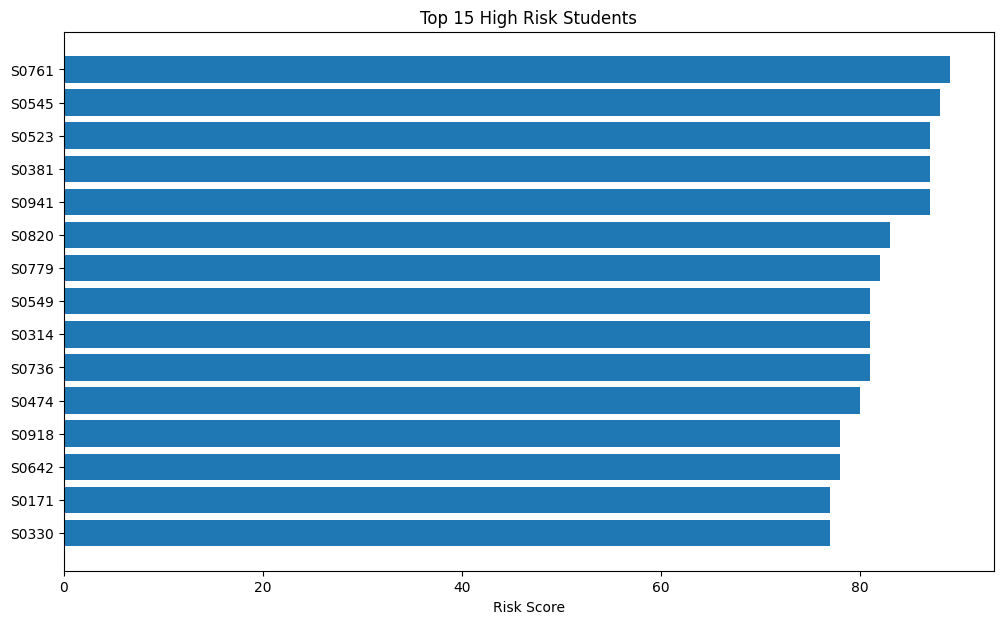

In [10]:
top_students = df.sort_values(
    "Burnout_Risk_Score",
    ascending=False
).head(15)

plt.figure(figsize=(12,7))

plt.barh(
    top_students["StudentID"],
    top_students["Burnout_Risk_Score"]
)

plt.gca().invert_yaxis()

plt.xlabel("Risk Score")

plt.title("Top 15 High Risk Students")

plt.show()

5. Faculty Alert System

In [11]:
high_risk = df[
    (df["Burnout_Risk_Level"]=="High") |
    (df["Academic_Disengagement"]=="Yes")
]

print("🚨 Students requiring Faculty Attention:",len(high_risk))

high_risk[[
    "StudentID",
    "Burnout_Risk_Level",
    "Dropout_Probability",
    "Academic_Disengagement"
]].head(20)

🚨 Students requiring Faculty Attention: 146


,StudentID,Burnout_Risk_Level,Dropout_Probability,Academic_Disengagement
16,S0017,Medium,39,Yes
21,S0022,Medium,61,Yes
23,S0024,Medium,66,Yes
35,S0036,Medium,20,Yes
43,S0044,High,82,Yes
45,S0046,Medium,46,Yes
48,S0049,Medium,32,Yes
70,S0071,Low,29,Yes
74,S0075,Medium,36,Yes
75,S0076,Medium,62,Yes


6. Intervention Strategy Dashboard

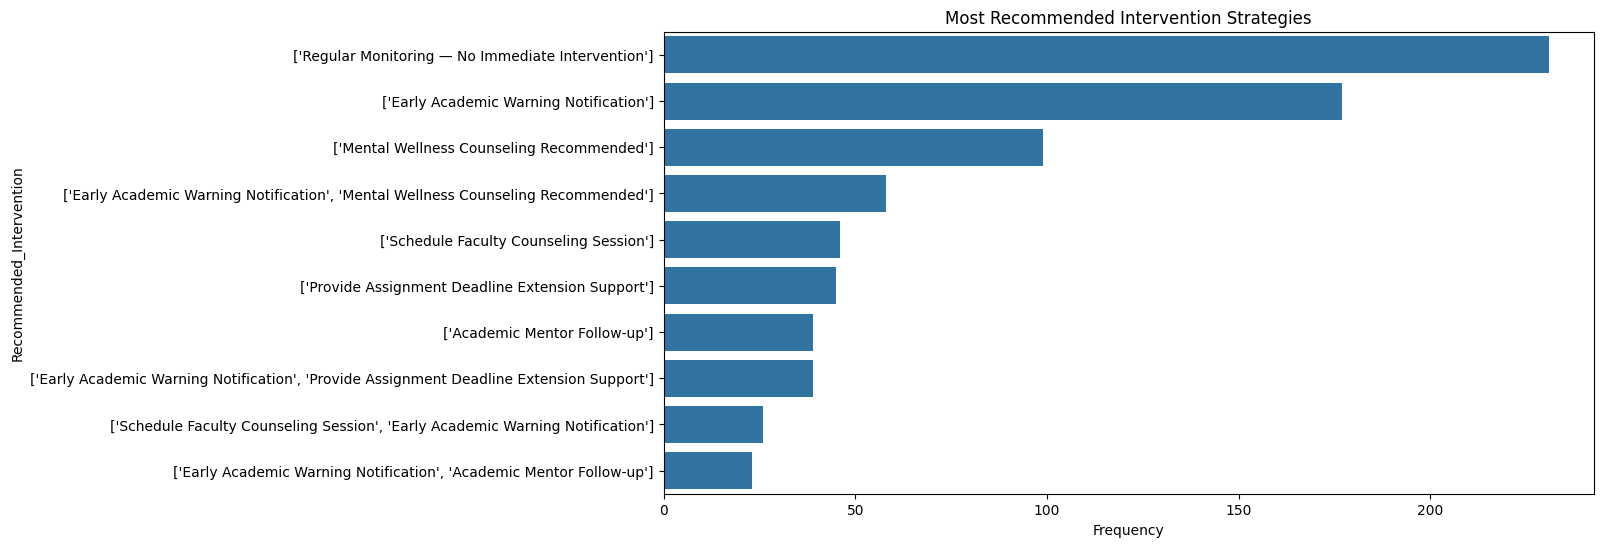

In [12]:
import seaborn as sns

interventions = df["Recommended_Intervention"].astype(str)

counts = interventions.value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=counts.values,
    y=counts.index
)

plt.xlabel("Frequency")

plt.title("Most Recommended Intervention Strategies")

plt.show()

# **Dashboard**

In [13]:
!pip install plotly shap seaborn --quiet

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
import shap

from sklearn.ensemble import RandomForestClassifier

In [15]:
df = pd.read_csv("/content/student_burnout_dataset_with_actions.csv")

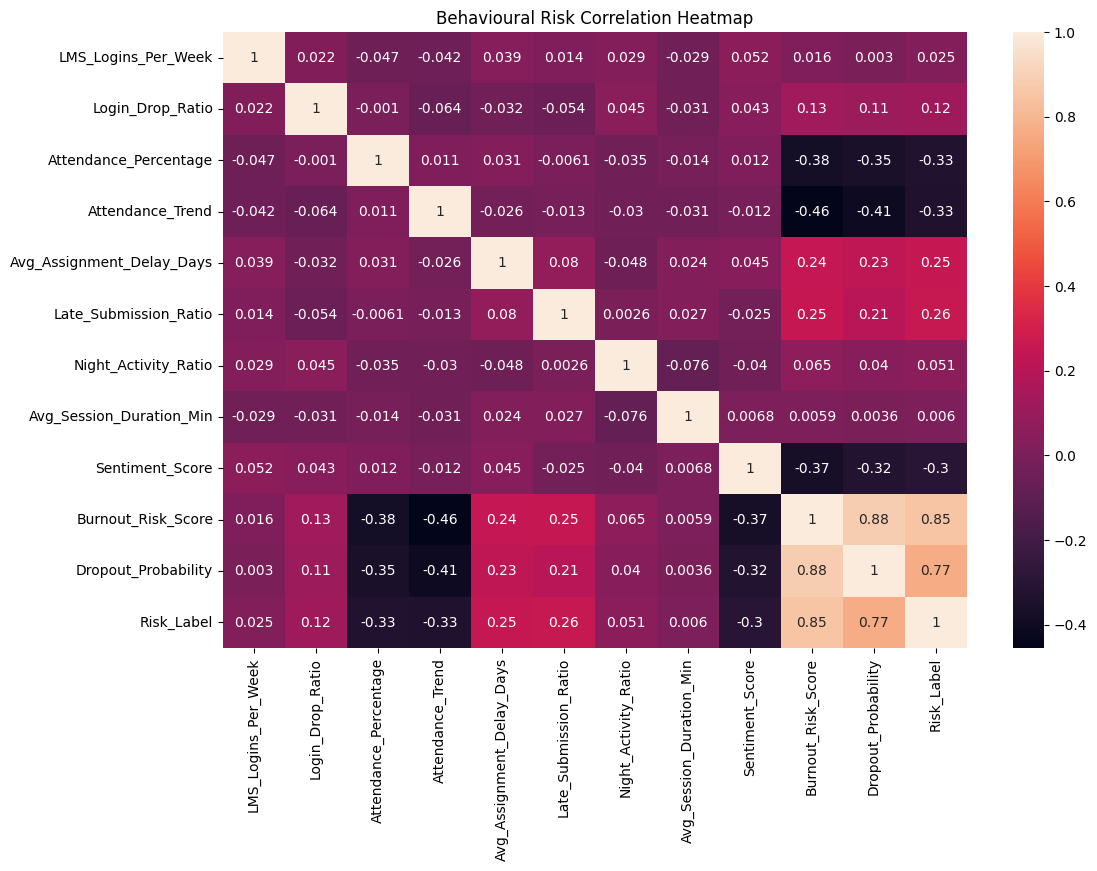

In [17]:
plt.figure(figsize=(12,8))

numeric=df.select_dtypes(include=np.number)

sns.heatmap(

numeric.corr(),

annot=True

)

plt.title("Behavioural Risk Correlation Heatmap")

plt.show()

In [23]:
print("UNIVERSITY SUMMARY")

print(

"Average Burnout Risk:",

round(df["Burnout_Risk_Score"].mean(),2)

)

print(

"High Risk Students:",

len(df[df["Burnout_Risk_Level"]=="High"])

)

print(

"Average Dropout Probability:",

round(df["Dropout_Probability"].mean(),2)

)

UNIVERSITY SUMMARY
Average Burnout Risk: 29.15
High Risk Students: 27
Average Dropout Probability: 29.81
